In [1]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

In [2]:
load_dotenv()

api_key = os.getenv("FOURSQUARE_API_KEY")

if not api_key:
    raise ValueError("No se encontró FOURSQUARE_API_KEY en el archivo .env")

In [3]:
url = "https://places-api.foursquare.com/places/search"

headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {api_key}",
    "X-Places-Api-Version": "2025-06-17"
}

In [12]:
params = {
    "near": "Teusaquillo, Bogotá, Colombia",
    "fsq_category_ids": "4bf58dd8d48988d1e0931735,4bf58dd8d48988d16d941735",
    "limit": 50
}

response = requests.get(
    url,
    headers=headers,
    params=params,
    timeout=10
)

print("Status code:", response.status_code)

Status code: 200


In [13]:
data = response.json()
places = data.get("results", [])

print("Número de resultados:", len(places))

Número de resultados: 50


In [14]:
registros = []

for place in places:
    categorias = place.get("categories", [])

    category_names = [
        cat.get("name")
        for cat in categorias
    ]

    category_ids = [
        cat.get("fsq_category_id")
        for cat in categorias
    ]

    primary_category = (
        categorias[0].get("name")
        if categorias
        else None
    )

    primary_category_id = (
        categorias[0].get("fsq_category_id")
        if categorias
        else None
    )

    registros.append({
        "fsq_place_id": place.get("fsq_place_id"),
        "name": place.get("name"),
        "latitude": place.get("latitude"),
        "longitude": place.get("longitude"),
        "distance": place.get("distance"),
        "primary_category": primary_category,
        "primary_category_id": primary_category_id,
        "categories": ", ".join(category_names),
        "category_ids": ", ".join(category_ids),
        "address": place.get("location", {}).get("formatted_address")
    })

df = pd.DataFrame(registros)

In [15]:
df.head(10)

,fsq_place_id,name,latitude,longitude,distance,primary_category,primary_category_id,categories,category_ids,address
0,4ecab8ff2da5cc0a1f417e9d,Juan Valdez Café,4.643856,-74.091203,673,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Calle 44 #50-96 (Cra 53), Bogotá, Bogotá D.C."
1,59a02aafd3cce839e5c436d7,Tostao',4.630838,-74.093030,1404,Coffee Shop,4bf58dd8d48988d1e0931735,"Coffee Shop, Bakery","4bf58dd8d48988d1e0931735, 4bf58dd8d48988d16a94...","Av Calle 24 #40-11 (Expoferias Carrera 40), Bo..."
2,5206d369498e22afdc47c1a9,Café Oma,4.647468,-74.101692,1899,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Centro Comercial Gran Estación, Bogotá, Bogotá..."
3,5092c63ee4b083652fa524aa,Juan Valdez Cafè,4.645632,-74.100274,1683,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Ciudad Empresarial Luis Carlos Sarmiento, Bogo..."
4,4ecffdef6d86bf39f2b912d6,Kamerino Futbol Klub,4.642775,-74.076535,1035,Café,4bf58dd8d48988d16d941735,"Café, Bar","4bf58dd8d48988d16d941735, 4bf58dd8d48988d11694...","Kr. 28 # 53a - 06, Bogotá, Bogotá D.C."
5,6274480f4fd63423141a28c6,Juan Valdez Café,4.649325,-74.078120,1237,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Bogotá, Bogotá D.C."
6,4ecab8ff2da5cc0a1f417efa,Juan Valdez Café,4.647146,-74.101806,1898,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,Av. Calle 26 #62-47 C.C. Gran Estación - Isla ...
7,4dbb8d44f7b1ab37dd48b176,Galería Café Libro 45,4.634123,-74.069083,2005,Café,4bf58dd8d48988d16d941735,Café,4bf58dd8d48988d16d941735,"Trasversal 15B # 46-35, Bogotá, Bogotá D.C."
8,5648acb638fa1680cf213ce2,Tempo Cycling,4.644480,-74.072860,1473,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Transversal 24 No 53D - 53, Bogotá, Bogotá D.C."
9,4fc79be2e4b06e4ecfe33c3d,Café Camerino,4.627278,-74.073887,2028,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,cra 20 #37-80


In [16]:
df[["name", "primary_category", "categories"]]

,name,primary_category,categories
0,Juan Valdez Café,Coffee Shop,Coffee Shop
1,Tostao',Coffee Shop,"Coffee Shop, Bakery"
2,Café Oma,Coffee Shop,Coffee Shop
3,Juan Valdez Cafè,Coffee Shop,Coffee Shop
4,Kamerino Futbol Klub,Café,"Café, Bar"
5,Juan Valdez Café,Coffee Shop,Coffee Shop
6,Juan Valdez Café,Coffee Shop,Coffee Shop
7,Galería Café Libro 45,Café,Café
8,Tempo Cycling,Coffee Shop,Coffee Shop
9,Café Camerino,Coffee Shop,Coffee Shop


Se conserva el establecimiento cuando, aunque tenga una categoría complementaria distinta, su actividad incluya efectivamente el consumo de café o funcione como cafetería. Se excluyen los registros cuya relación con Café o Coffee Shop sea secundaria o inconsistente con la actividad real del establecimiento.


In [18]:
df_revision = df[
    ["fsq_place_id", "name", "primary_category", "categories", "address"]
].copy()

df_revision

,fsq_place_id,name,primary_category,categories,address
0,4ecab8ff2da5cc0a1f417e9d,Juan Valdez Café,Coffee Shop,Coffee Shop,"Calle 44 #50-96 (Cra 53), Bogotá, Bogotá D.C."
1,59a02aafd3cce839e5c436d7,Tostao',Coffee Shop,"Coffee Shop, Bakery","Av Calle 24 #40-11 (Expoferias Carrera 40), Bo..."
2,5206d369498e22afdc47c1a9,Café Oma,Coffee Shop,Coffee Shop,"Centro Comercial Gran Estación, Bogotá, Bogotá..."
3,5092c63ee4b083652fa524aa,Juan Valdez Cafè,Coffee Shop,Coffee Shop,"Ciudad Empresarial Luis Carlos Sarmiento, Bogo..."
4,4ecffdef6d86bf39f2b912d6,Kamerino Futbol Klub,Café,"Café, Bar","Kr. 28 # 53a - 06, Bogotá, Bogotá D.C."
5,6274480f4fd63423141a28c6,Juan Valdez Café,Coffee Shop,Coffee Shop,"Bogotá, Bogotá D.C."
6,4ecab8ff2da5cc0a1f417efa,Juan Valdez Café,Coffee Shop,Coffee Shop,Av. Calle 26 #62-47 C.C. Gran Estación - Isla ...
7,4dbb8d44f7b1ab37dd48b176,Galería Café Libro 45,Café,Café,"Trasversal 15B # 46-35, Bogotá, Bogotá D.C."
8,5648acb638fa1680cf213ce2,Tempo Cycling,Coffee Shop,Coffee Shop,"Transversal 24 No 53D - 53, Bogotá, Bogotá D.C."
9,4fc79be2e4b06e4ecfe33c3d,Café Camerino,Coffee Shop,Coffee Shop,cra 20 #37-80


In [19]:
nombres_excluir = [
    "Sharmier Chocolatier Galerías",
    "Empanadas Típicas",
    "Kamerino Futbol Klub",
    "Lacteos Campilac"
]

In [20]:
df[
    df["name"].isin(nombres_excluir)
][
    ["fsq_place_id", "name", "primary_category", "categories", "address"]
]

,fsq_place_id,name,primary_category,categories,address
4,4ecffdef6d86bf39f2b912d6,Kamerino Futbol Klub,Café,"Café, Bar","Kr. 28 # 53a - 06, Bogotá, Bogotá D.C."
25,5138ca7be4b0245fe38bf2d6,Lacteos Campilac,Coffee Shop,Coffee Shop,"Carrera 52 No 44 26, Bogotá, Bogotá D.C."
27,4e1392dfa809548274a487c9,Empanadas Típicas,Coffee Shop,"Coffee Shop, Latin American Restaurant","Carrera 53 (53 - 57), Bogotá, Bogotá D.C."
43,4e38389318a8470916d2efea,Sharmier Chocolatier Galerías,Dessert Shop,"Dessert Shop, Café",


In [21]:
ids_excluir = df.loc[
    df["name"].isin(nombres_excluir),
    "fsq_place_id"
].tolist()

In [22]:
df_cafeterias = df[
    ~df["fsq_place_id"].isin(ids_excluir)
].copy()

In [23]:
print("Registros iniciales:", len(df))
print("Registros excluidos:", len(ids_excluir))
print("Registros finales:", len(df_cafeterias))

Registros iniciales: 50
Registros excluidos: 4
Registros finales: 46


Depuración de resultados. La consulta se realizó utilizando los identificadores oficiales de las categorías Coffee Shop y Café de Foursquare. Debido a que algunos establecimientos presentaban clasificaciones múltiples o inconsistentes con el objeto de estudio, se realizó una revisión de los casos ambiguos. Se excluyeron únicamente aquellos establecimientos cuya actividad principal no correspondía al funcionamiento de una cafetería, conservando negocios mixtos —como panaderías o espacios temáticos— cuando el consumo de café hacía parte efectiva de su oferta.

#### Verificación de la ubicación de los establecimientos: 

In [ ]:
# pip install geopandas

   ---------------------------------------- 0.0/23.9 MB ? eta -:--:--
   -- ------------------------------------- 1.6/23.9 MB 6.5 MB/s eta 0:00:04
   ----- ---------------------------------- 3.1/23.9 MB 7.1 MB/s eta 0:00:03
   ------- -------------------------------- 4.7/23.9 MB 7.3 MB/s eta 0:00:03
   ---------- ----------------------------- 6.3/23.9 MB 7.3 MB/s eta 0:00:03
   ------------- -------------------------- 7.9/23.9 MB 7.3 MB/s eta 0:00:03
   ---------------- ----------------------- 9.7/23.9 MB 7.4 MB/s eta 0:00:02
   ------------------ --------------------- 11.3/23.9 MB 7.4 MB/s eta 0:00:02
   --------------------- ------------------ 12.8/23.9 MB 7.5 MB/s eta 0:00:02
   ------------------------- -------------- 14.9/23.9 MB 7.5 MB/s eta 0:00:02
   --------------------------- ------------ 16.5/23.9 MB 7.5 MB/s eta 0:00:01
   ----------------------------- ---------- 17.8/23.9 MB 7.4 MB/s eta 0:00:01
   -------------------------------- ------- 19.4/23.9 MB 7.4 MB/s eta 0:00:01


In [25]:
import geopandas as gpd

In [28]:

localidades = gpd.read_file("Localidades Bogota.json")

In [29]:
localidades.head()

,OBJECTID,LocNombre,LocAAdmini,LocArea,LocCodigo,SHAPE_Length,SHAPE_Area,geometry
0,81,ANTONIO NARIÑO,Acuerdo 117 de 2003,4.879543e+06,15,0.108973,0.000397,"POLYGON ((-74.13075 4.59335, -74.12917 4.59327..."
1,82,TUNJUELITO,Acuerdo 117 de 2003,9.910940e+06,06,0.210542,0.000807,"POLYGON ((-74.13777 4.59489, -74.13165 4.59363..."
2,83,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1.383408e+07,18,0.174513,0.001126,"POLYGON ((-74.12803 4.59254, -74.12777 4.59233..."
3,84,CANDELARIA,Acuerdo 117 de 2003,2.060243e+06,17,0.067158,0.000168,"POLYGON ((-74.06621 4.60317, -74.0662 4.60317,..."
4,85,BARRIOS UNIDOS,Acuerdo 8 de 1977,1.190345e+07,12,0.121180,0.000969,"POLYGON ((-74.05725 4.68684, -74.06249 4.65594..."


In [30]:
localidades.columns

Index(['OBJECTID', 'LocNombre', 'LocAAdmini', 'LocArea', 'LocCodigo',
       'SHAPE_Length', 'SHAPE_Area', 'geometry'],
      dtype='object')

In [31]:
teusaquillo = localidades[
    localidades["LocNombre"].str.upper() == "TEUSAQUILLO"
].copy()

In [32]:
print(teusaquillo[["LocNombre"]])

     LocNombre
5  TEUSAQUILLO


In [33]:
print(localidades.crs)

EPSG:4686


In [35]:
cafeterias_geo = gpd.GeoDataFrame(
    df_cafeterias.copy(),
    geometry=gpd.points_from_xy(
        df_cafeterias["longitude"],
        df_cafeterias["latitude"]
    ),
    crs="EPSG:4326"
)

In [36]:
print(cafeterias_geo.crs)

EPSG:4326


In [37]:
teusaquillo_4326 = teusaquillo.to_crs("EPSG:4326")

In [38]:
print(teusaquillo_4326.crs)
print(cafeterias_geo.crs)

EPSG:4326
EPSG:4326


In [39]:
cafeterias_teusaquillo = gpd.sjoin(
    cafeterias_geo,
    teusaquillo_4326[["LocNombre", "geometry"]],
    how="inner",
    predicate="within"
)

In [40]:
print("Cafeterías antes del filtro geográfico:", len(cafeterias_geo))
print("Cafeterías dentro de Teusaquillo:", len(cafeterias_teusaquillo))

Cafeterías antes del filtro geográfico: 46
Cafeterías dentro de Teusaquillo: 46


In [41]:
cafeterias_teusaquillo[
    ["name", "address", "latitude", "longitude", "LocNombre"]
]

,name,address,latitude,longitude,LocNombre
0,Juan Valdez Café,"Calle 44 #50-96 (Cra 53), Bogotá, Bogotá D.C.",4.643856,-74.091203,TEUSAQUILLO
1,Tostao',"Av Calle 24 #40-11 (Expoferias Carrera 40), Bo...",4.630838,-74.093030,TEUSAQUILLO
2,Café Oma,"Centro Comercial Gran Estación, Bogotá, Bogotá...",4.647468,-74.101692,TEUSAQUILLO
3,Juan Valdez Cafè,"Ciudad Empresarial Luis Carlos Sarmiento, Bogo...",4.645632,-74.100274,TEUSAQUILLO
5,Juan Valdez Café,"Bogotá, Bogotá D.C.",4.649325,-74.078120,TEUSAQUILLO
6,Juan Valdez Café,Av. Calle 26 #62-47 C.C. Gran Estación - Isla ...,4.647146,-74.101806,TEUSAQUILLO
7,Galería Café Libro 45,"Trasversal 15B # 46-35, Bogotá, Bogotá D.C.",4.634123,-74.069083,TEUSAQUILLO
8,Tempo Cycling,"Transversal 24 No 53D - 53, Bogotá, Bogotá D.C.",4.644480,-74.072860,TEUSAQUILLO
9,Café Camerino,cra 20 #37-80,4.627278,-74.073887,TEUSAQUILLO
10,Vereda Central ParkWay,"Carrera 19 # 36 - 55, Bogotá, Bogotá D.C.",4.625843,-74.073360,TEUSAQUILLO


La consulta inicial se realizó utilizando las categorías oficiales Coffee Shop y Café de Foursquare y la ubicación Teusaquillo, Bogotá. Posteriormente, las coordenadas de los establecimientos fueron contrastadas con el polígono oficial de la localidad de Teusaquillo mediante un cruce espacial en GeoPandas. Todos los registros depurados quedaron dentro del límite administrativo de la localidad.

#### Verificación de duplicados: 

In [42]:
print("Duplicados por fsq_place_id:",
      cafeterias_teusaquillo["fsq_place_id"].duplicated().sum())

Duplicados por fsq_place_id: 0


In [43]:
duplicados_posibles = cafeterias_teusaquillo[
    cafeterias_teusaquillo.duplicated(
        subset=["name", "latitude", "longitude"],
        keep=False
    )
].sort_values(["name", "latitude", "longitude"])

duplicados_posibles[
    ["fsq_place_id", "name", "latitude", "longitude", "address"]
]

,fsq_place_id,name,latitude,longitude,address


In [ ]:
# Cantidad total de establecimientos: 

print(f"Número final de cafeterías: {len(cafeterias_teusaquillo)}")
print(f"Duplicados por ID: {cafeterias_teusaquillo['fsq_place_id'].duplicated().sum()}")
print(f"Valores faltantes por columna:\n{cafeterias_teusaquillo.isna().sum()}")

Número final de cafeterías: 46
Duplicados por ID: 0
Valores faltantes por columna:
fsq_place_id           0
name                   0
latitude               0
longitude              0
distance               0
primary_category       0
primary_category_id    0
categories             0
category_ids           0
address                0
geometry               0
index_right            0
LocNombre              0
dtype: int64


In [45]:
# Distribución entre Café, Coffee Shop y categorías secundarias: 

cafeterias_teusaquillo["primary_category"].value_counts()

primary_category
Coffee Shop      23
Café             21
Bicycle Store     1
Bakery            1
Name: count, dtype: int64

In [46]:
cafeterias_teusaquillo["categories"].value_counts().head(15)

categories
Coffee Shop                  19
Café                         18
Coffee Shop, Bakery           3
Café, Bakery                  1
Café, Coffee Shop             1
Coffee Shop, Café             1
Café, Coworking Space         1
Bicycle Store, Café           1
Bakery, Café, Coffee Shop     1
Name: count, dtype: int64

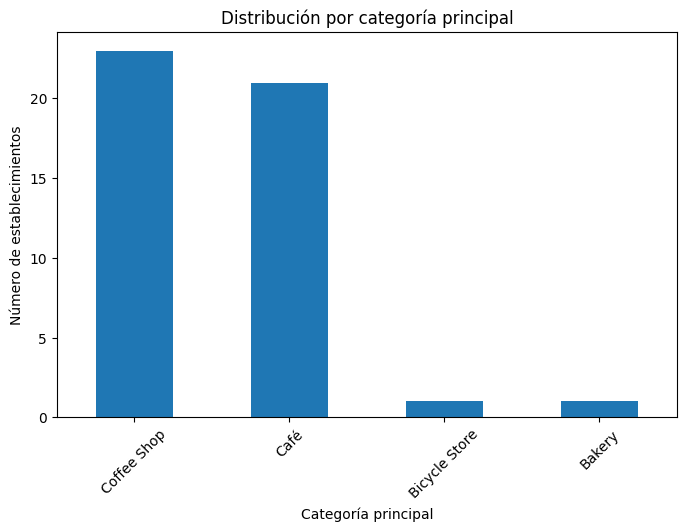

In [52]:
conteo = cafeterias_teusaquillo["primary_category"].value_counts()

conteo.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución por categoría principal")
plt.xlabel("Categoría principal")
plt.ylabel("Número de establecimientos")
plt.xticks(rotation=45)
plt.show()

La muestra final estuvo compuesta por 46 establecimientos. De ellos, 23 fueron clasificados principalmente como Coffee Shop y 21 como Café. Los dos casos restantes correspondieron a establecimientos híbridos validados manualmente como espacios de consumo de café. En términos de clasificación completa, 37 de los 46 registros presentaron exclusivamente las categorías Coffee Shop o Café, mientras que una proporción menor combinó la actividad de cafetería con panadería, coworking u otros conceptos.

In [ ]:
# pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 6.9 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.2 MB 6.7 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 6.6 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 6.4 MB/s  0:00:01
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------------- ------- 1.3/1.6 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------- -------------------------------- 1.3/7.2 MB 6.7 MB/s eta 0:00:01
   ------------- ----------------------

#### Verificación de la distribución y concentración de cafeterías: 

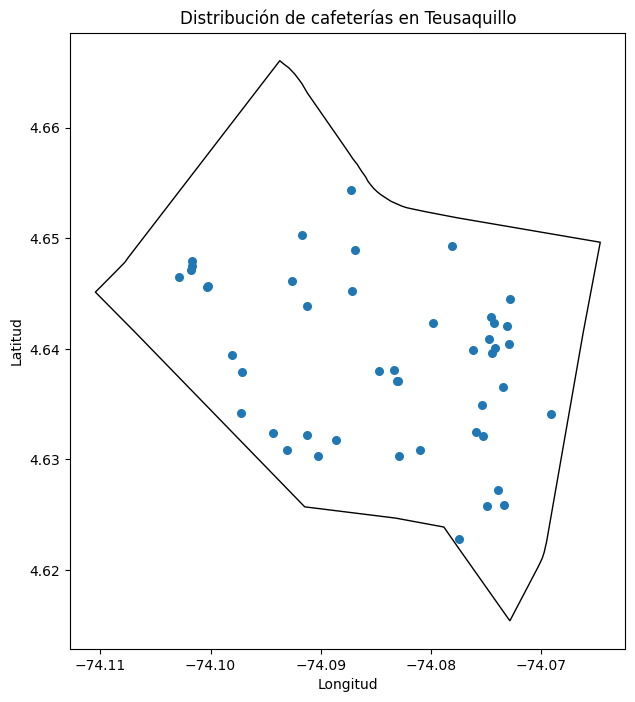

In [ ]:
#MApa de distribución de cafeterías en Teusaquillo: 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

teusaquillo_4326.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black"
)

cafeterias_teusaquillo.plot(
    ax=ax,
    markersize=30
)

ax.set_title("Distribución de cafeterías en Teusaquillo")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.show()

In [53]:
cafeterias_proj = cafeterias_teusaquillo.to_crs(epsg=3116)
teusaquillo_proj = teusaquillo_4326.to_crs(epsg=3116)

In [54]:
#Creación de una cuadrícula de 500 metros sobre Teusaquillo: 

import numpy as np
from shapely.geometry import box
import geopandas as gpd

minx, miny, maxx, maxy = teusaquillo_proj.total_bounds

cell_size = 500

grid_cells = []

for x0 in np.arange(minx, maxx, cell_size):
    for y0 in np.arange(miny, maxy, cell_size):
        x1 = x0 + cell_size
        y1 = y0 + cell_size
        grid_cells.append(box(x0, y0, x1, y1))

grid = gpd.GeoDataFrame(
    geometry=grid_cells,
    crs=teusaquillo_proj.crs
)

In [57]:
cafeterias_proj = cafeterias_teusaquillo.drop(
    columns=["index_right"],
    errors="ignore"
).to_crs(epsg=3116)

In [58]:
grid_teusaquillo = grid_teusaquillo.drop(
    columns=["index_right"],
    errors="ignore"
)

In [59]:
cafes_por_celda = gpd.sjoin(
    cafeterias_proj,
    grid_teusaquillo,
    how="left",
    predicate="within"
)

conteo_celdas = cafes_por_celda.groupby("index_right").size()

grid_teusaquillo["n_cafeterias"] = (
    grid_teusaquillo.index.map(conteo_celdas).fillna(0)
)

In [60]:
grid_teusaquillo["n_cafeterias"].describe()

count    77.000000
mean      0.597403
std       0.921380
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       4.000000
Name: n_cafeterias, dtype: float64

In [61]:
grid_teusaquillo.sort_values(
    "n_cafeterias",
    ascending=False
)[["n_cafeterias"]].head(10)

,n_cafeterias
65,4.0
27,3.0
56,3.0
6,3.0
9,2.0
54,2.0
46,2.0
47,2.0
45,2.0
17,2.0


In [62]:
grid_teusaquillo["n_cafeterias"].value_counts().sort_index()

n_cafeterias
0.0    48
1.0    17
2.0     8
3.0     3
4.0     1
Name: count, dtype: int64

In [63]:
celdas_con_cafes = (grid_teusaquillo["n_cafeterias"] > 0).sum()

print("Celdas totales:", len(grid_teusaquillo))
print("Celdas con al menos una cafetería:", celdas_con_cafes)
print(
    "Porcentaje de celdas con cafeterías:",
    round(celdas_con_cafes / len(grid_teusaquillo) * 100, 1),
    "%"
)

Celdas totales: 77
Celdas con al menos una cafetería: 29
Porcentaje de celdas con cafeterías: 37.7 %


Se utilizaron celdas de 500 m como unidad de análisis espacial, buscando un equilibrio entre nivel de detalle y número de establecimientos por unidad. Sin embargo, aquellas celdas que quedaron en los límites de la localidad, tienen un tamño menor que las celdas que no están en los límites. Los resultados deben interpretarse considerando que el patrón observado puede variar si se modifica el tamaño de la cuadrícula.

El análisis espacial muestra que la oferta de cafeterías en Teusaquillo no se distribuye de manera uniforme. De las 77 celdas generadas sobre la localidad, 48 no contienen cafeterías, mientras que solo 29 presentan al menos un establecimiento, lo que equivale al 37,7% de las celdas analizadas. La mayor parte de las zonas con presencia de cafeterías concentra pocos establecimientos: 17 celdas contienen una cafetería, 8 contienen dos, 3 contienen tres y solo una celda alcanza una concentración de cuatro cafeterías. Estos resultados sugieren la existencia de focos específicos de concentración comercial, mientras que amplias áreas de la localidad presentan una oferta baja o nula.

Desde una perspectiva comercial, este patrón puede reflejar zonas con mayor actividad peatonal, comercial, institucional o de servicios, donde la demanda potencial favorece la concentración de cafeterías. Al mismo tiempo, las áreas con menor presencia podrían representar sectores de menor demanda o, eventualmente, espacios con menor oferta relativa. Sin embargo, identificar oportunidades de mercado requeriría complementar este análisis con variables como población flotante, uso del suelo, presencia de universidades, oficinas, estaciones de transporte y competencia existente.


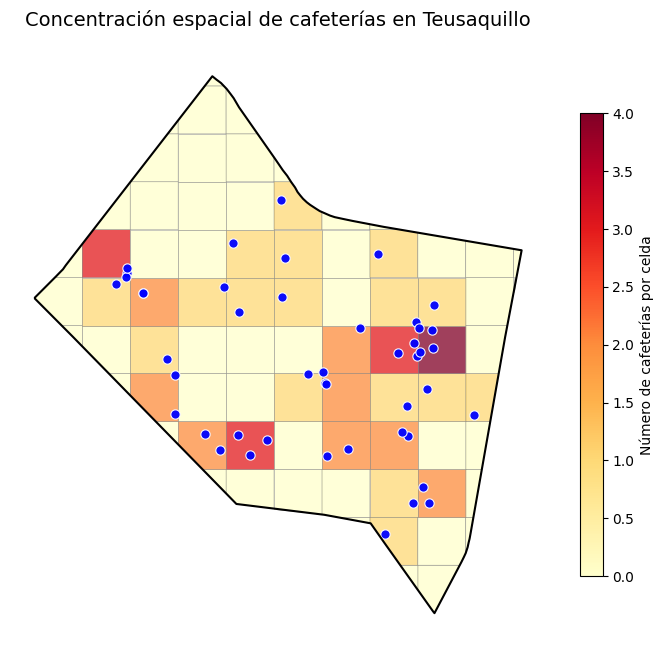

In [72]:
fig, ax = plt.subplots(figsize=(7, 7))

# 1. Cuadrícula con escala de color para concentración
grid_teusaquillo.plot(
    column="n_cafeterias",
    cmap="YlOrRd",          # escala de amarillo a rojo
    legend=True,
    ax=ax,
    edgecolor="gray",
    linewidth=0.4,
    alpha=0.75,
    legend_kwds={
        "label": "Número de cafeterías por celda",
        "shrink": 0.7
    }
)

# 2. Límite de Teusaquillo
teusaquillo_proj.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

# 3. Puntos de cafeterías más visibles
cafeterias_proj.plot(
    ax=ax,
    color="blue",
    markersize=45,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

ax.set_title("Concentración espacial de cafeterías en Teusaquillo", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

#### Guardamos versión tabular: 

In [50]:
df_final = pd.DataFrame(
    cafeterias_teusaquillo.drop(columns=["geometry", "index_right"])
)

df_final.to_csv(
    "cafeterias_teusaquillo_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

In [73]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\anton\OneDrive - Universidad de la Sabana (1)\Posgrado MAA\Semestre 3\Herramientas de Computación en la Nube
['.env', '.vscode', 'analisis_cafeterias_teusaquillo.ipynb', 'AWS 1.png', 'AWS.png', 'cafeterias_teusaquillo_limpio.csv', 'Deliverable 2 - EC2 experimental environment for online analytics.pdf', 'Extensiones instaladas VSCode.png', 'Guía Práctica 3 - Aprovisionamiento de instancias de Elastic Compute Cloud de AWS (EC2).pdf', 'Herramientas de Computación en la Nube.rar', 'Intalación Miniconda.png', 'Localidades Bogota.json', 'OpenWeatherMap Service Sign-up and Configuration.pdf', 'prueba_foursquare.py', 'Prueba_seguridad.png', 'prueba_seguridad.py']


In [75]:
pip install boto3

   ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
   --- ------------------------------------ 1.6/15.9 MB 8.4 MB/s eta 0:00:02
   ------- -------------------------------- 3.1/15.9 MB 8.0 MB/s eta 0:00:02
   ----------- ---------------------------- 4.7/15.9 MB 7.9 MB/s eta 0:00:02
   ---------------- ----------------------- 6.6/15.9 MB 7.9 MB/s eta 0:00:02
   -------------------- ------------------- 8.1/15.9 MB 7.7 MB/s eta 0:00:02
   ------------------------ --------------- 9.7/15.9 MB 7.6 MB/s eta 0:00:01
   ----------------------------- ---------- 11.5/15.9 MB 7.7 MB/s eta 0:00:01
   -------------------------------- ------- 13.1/15.9 MB 7.7 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------  15.7/15.9 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 15.9/15.9 MB 7.4 MB/s  0:00:02

   ---------------------------------------- 0/4 [jmespath]
   ------------------

In [76]:
import os
import boto3
from dotenv import load_dotenv

load_dotenv()

bucket_name = os.getenv("S3_BUCKET_NAME")
region = os.getenv("AWS_DEFAULT_REGION")

print("Bucket:", bucket_name)
print("Región:", region)

Bucket: maa-cafeterias-teusaquillo-ag-2026
Región: us-east-1


In [79]:
s3_client = boto3.client(
    "s3",
    region_name=region
)

In [77]:
archivo_local = "cafeterias_teusaquillo_limpio.csv"

s3_key = "raw-zone/cafeterias/cafeterias_teusaquillo_limpio.csv"

In [80]:
try:
    s3_client.upload_file(
        archivo_local,
        bucket_name,
        s3_key
    )

    print("Carga exitosa.")
    print(f"s3://{bucket_name}/{s3_key}")

except Exception as e:
    print("Error durante la carga:")
    print(e)

Carga exitosa.
s3://maa-cafeterias-teusaquillo-ag-2026/raw-zone/cafeterias/cafeterias_teusaquillo_limpio.csv


In [81]:
response = s3_client.list_objects_v2(
    Bucket=bucket_name,
    Prefix="raw-zone/cafeterias/"
)

for obj in response.get("Contents", []):
    print(obj["Key"], "-", obj["Size"], "bytes")

raw-zone/cafeterias/cafeterias_teusaquillo_limpio.csv - 9466 bytes
